# 1. Introduction & Objective

## Benchmarking ResNet50 Model for Image Classification

### 📌 Objective  
In this notebook, we **replicate the official benchmark ResNet50 model** from the Rakuten Challenge.  
This serves as a **baseline** to evaluate and compare future CNN models.

We implement the reference setup with:
- **ResNet50 pretrained on ImageNet**
- **27 layers unfrozen** (including 8 convolutional layers)
- **Image preprocessing using `ImageDataGenerator`**
- **Evaluation based on Weighted F1-score**

### 🎯 Goal  
- Reproduce the **exact benchmark architecture** (as described in the challenge reference).  
- **Establish a baseline performance (Weighted F1-score = 0.5534)** for comparison.  
- Use this as a **reference point** when testing other custom CNN architectures.


# 2. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import sys
from pathlib import Path
import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score


# Setup dynamic project paths
CURRENT_DIR = Path(os.getcwd()).resolve()
PROJECT_ROOT = CURRENT_DIR.parents[2]
sys.path.append(str(PROJECT_ROOT))

def get_relative_path(absolute_path):
    return str(Path(absolute_path).relative_to(PROJECT_ROOT))

print(f"Project Root Directory: {PROJECT_ROOT.name}")

# Load project config
import config

# sys.path.append(str(Path().resolve().parent.parent.parent / "src"))

Project Root Directory: Data_Scientist_Rakuten_Project-main


## 3.  Loading Data

In this step, we load the preprocessed and pre-split datasets created in a previous notebook.

These include:

- `X_train_split.pkl` → 80% of the data for training  
- `X_val_split.pkl` → 20% of the data for validation  
- `prdtypecode_mapping.pkl` → Mapping of product codes to integer labels (0 to 26)


In [3]:
from src.data_preprocessing.load_image_metadata import load_image_metadata

# Call the function
X_train_split, X_val_split, prdtypecode_mapping = load_image_metadata()

[✔] Loaded `X_train_split` | Type: <class 'pandas.core.frame.DataFrame'>


,designation,description,text,productid,imageid,prdtypecode,prdtypecode_encoded,Label,image_name
1887,porte bebe violet rouge trois mere multifoncti...,Porte bébé Violet et rouge Trois-en-un mère mu...,porte bebe violet rouge trois mere multifoncti...,3050424970,1187504001,1320,12,Early Childhood,image_1187504001_product_3050424970.jpg
70389,jesus cahiers libre avenir,Prêtre autrement.,jesus cahiers libre avenir pretre autrement,131641431,885888766,10,0,Adult Books,image_885888766_product_131641431.jpg
59835,chambre paillasson forme coeur tapis fluffy ta...,Chambre Paillasson en forme de coeur Tapis Tap...,chambre paillasson forme coeur tapis fluffy ch...,4197486437,1313030973,1560,13,Interior Furniture and Bedding,image_1313030973_product_4197486437.jpg


[✔] Loaded `X_val_split` | Type: <class 'pandas.core.frame.DataFrame'>


,designation,description,text,productid,imageid,prdtypecode,prdtypecode_encoded,Label,image_name
81432,bas filles enfants enfants collant coton bebe ...,Filles Bas Enfants Enfants Collant Coton bébé ...,bas filles enfants collant coton bebe stocking...,3898715946,1261369347,1301,10,Accessories for Children,image_1261369347_product_3898715946.jpg
44734,cosmic planete series peluche capuche couvertu...,Cosmic Planète Series en peluche avec capuche ...,cosmic planete series peluche capuche couvertu...,4205111198,1315322348,1560,13,Interior Furniture and Bedding,image_1315322348_product_4205111198.jpg
59366,dolphin robot electrique piscine fond parois l...,dolphin dolphin - robot électrique de piscine ...,dolphin robot electrique piscine fond parois l...,3894338575,1260564839,2583,23,Piscine and Spa,image_1260564839_product_3894338575.jpg


[✔] Loaded `prdtypecode_mapping` | Type: <class 'dict'>
 Sample entries from `prdtypecode_mapping`: [(10, 0), (40, 1), (50, 2), (60, 3), (1140, 4)]


# 4. Define ResNet50 Benchmark Model

**Reference**: [Rakuten Challenge – Official Benchmark Description](https://challengedata.ens.fr/participants/challenges/35/)

The official Rakuten benchmark for image classification is based on a **ResNet50 model pretrained on ImageNet**.  
As described in the challenge:

- **27 layers are unfrozen**, including **8 convolutional layers** (for fine-tuning).
- Two additional layers are appended:
  - A `Dense(512, activation='relu')` layer
  - A final classification `Dense(27, activation='softmax')` layer for product type prediction

**Model Parameters (Benchmark Reference)**:
- **Trainable parameters**: `12,144,667`
- **Non-trainable parameters**: `23,643,035`

This setup is used as the baseline image model in the competition, and will help us evaluate future improvements in performance (e.g., augmentation, fine-tuning, etc.).


In [5]:
def create_resnet_model(input_shape=(224, 224, 3), num_classes=27):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape, pooling='avg')
    
    # Unfreeze top 27 layers
    for layer in base_model.layers[-27:]:
        layer.trainable = True

    x = Dense(512, activation='relu')(base_model.output)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_resnet_model()


# 5. Load Image Data with `ImageDataGenerator`

We use `ImageDataGenerator` to load and preprocess image data directly from the DataFrames created during the 80/20 split.

Key steps:
- **Rescale** pixel values to [0, 1] range (`1./255`).
- **Load images using `flow_from_dataframe`**, referencing `X_train_split` and `X_val_split`.
- Use the **`image_name`** column as the image file path.
- Use the **`prdtypecode_encoded`** column as the label (converted to string for compatibility).
- Set the image size to **(224, 224)** as expected by ResNet50.


In [15]:
importlib.reload(config)  # Reload config to ensure any updates are applied

# Use config path for image directory
image_dir = Path(config.RAW_IMAGE_TRAIN_DIR)


image_datagen = ImageDataGenerator(rescale=1. / 255)

# Define common parameters
image_target_size = (224, 224)
batch_size = 32
class_mode = "sparse"

# Directory where image files are stored
image_dir = Path(config.RAW_IMAGE_TRAIN_DIR)

# Convert target column to string for compatibility with class_mode='sparse'
X_train_split["prdtypecode_encoded"] = X_train_split["prdtypecode_encoded"].astype(str)
X_val_split["prdtypecode_encoded"] = X_val_split["prdtypecode_encoded"].astype(str)



# Training generator
train_generator = image_datagen.flow_from_dataframe(
    dataframe=X_train_split,
    directory=image_dir,
    x_col="image_name",
    y_col="prdtypecode_encoded",
    target_size=image_target_size,
    batch_size=batch_size,
    class_mode=class_mode,
    shuffle=True,
    seed=42
)

# Validation generator
val_generator = image_datagen.flow_from_dataframe(
    dataframe=X_val_split,
    directory=image_dir,
    x_col="image_name",
    y_col="prdtypecode_encoded",
    target_size=image_target_size,
    batch_size=batch_size,
    class_mode=class_mode,
    shuffle=False
)

Found 67932 validated image filenames belonging to 27 classes.
Found 16984 validated image filenames belonging to 27 classes.


# 6. Train the Model

We train the ResNet50 model with the following setup:

- **Batch size**: 32  
- **Epochs**: 10  
- **Evaluation**: Performed on the validation set  
- **EarlyStopping**: Stops training if validation loss doesn't improve after 2 consecutive epochs (to avoid overfitting).


In [17]:
# EarlyStopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    callbacks=[early_stop]
)

Epoch 1/10
2123/2123 [==============================] - 512s 235ms/step - loss: 1.9762 - accuracy: 0.4256 - val_loss: 2.4743 - val_accuracy: 0.3279
Epoch 2/10
2123/2123 [==============================] - 510s 240ms/step - loss: 1.6176 - accuracy: 0.5183 - val_loss: 2.3927 - val_accuracy: 0.3673
Epoch 3/10
2123/2123 [==============================] - 505s 238ms/step - loss: 1.4405 - accuracy: 0.5666 - val_loss: 3.4838 - val_accuracy: 0.3129
Epoch 4/10
2123/2123 [==============================] - 510s 240ms/step - loss: 1.2755 - accuracy: 0.6097 - val_loss: 1.9939 - val_accuracy: 0.4538
Epoch 5/10
2123/2123 [==============================] - 521s 245ms/step - loss: 1.0979 - accuracy: 0.6587 - val_loss: 1.4902 - val_accuracy: 0.5634
Epoch 6/10
2123/2123 [==============================] - 517s 243ms/step - loss: 0.8951 - accuracy: 0.7158 - val_loss: 1.8329 - val_accuracy: 0.4825
Epoch 7/10
2123/2123 [==============================] - 540s 254ms/step - loss: 0.6699 - accuracy: 0.7814 - val_

# 7. Model Evaluation

## 7.1 Learning Curves: Accuracy & Loss

In [19]:
def plot_resnet_learning_curves(history, title="Learning Curves - ResNet50 Benchmark Model"):
    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


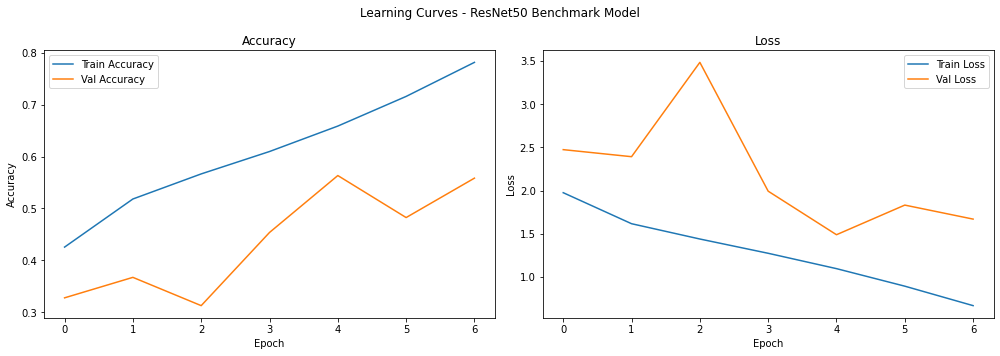

In [21]:
plot_resnet_learning_curves(history)

## 7.2  Evaluation Metrics

- **F1-score weighted**
- **Précision**
- **Recal**

In [23]:
y_true = val_generator.classes
y_pred = np.argmax(model.predict(val_generator), axis=1)

f1 = f1_score(y_true, y_pred, average="weighted")
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")

print(f" Weighted F1-score: {f1:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Recall: {recall:.4f}")

531/531 [==============================] - 66s 123ms/step
 Weighted F1-score: 0.5660
 Precision: 0.5917
 Recall: 0.5634


## 7.3 Classification Report


In [25]:
report = classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys())
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       0.44      0.73      0.55       623
           1       0.69      0.59      0.64       502
          10       0.49      0.47      0.48       161
          11       0.26      0.32      0.28       498
          12       0.41      0.31      0.35       648
          13       0.45      0.56      0.50      1015
          14       0.82      0.69      0.75       861
          15       0.32      0.65      0.43       161
          16       0.38      0.58      0.46       999
          17       0.46      0.07      0.13       165
          18       0.80      0.68      0.73       952
          19       0.57      0.69      0.63       955
           2       0.34      0.33      0.34       336
          20       0.47      0.45      0.46       284
          21       0.51      0.69      0.58       998
          22       0.52      0.29      0.37       518
          23       0.86      0.68      0.76      2042
   

## 7.4 Confusion Matrix: Error Analysis

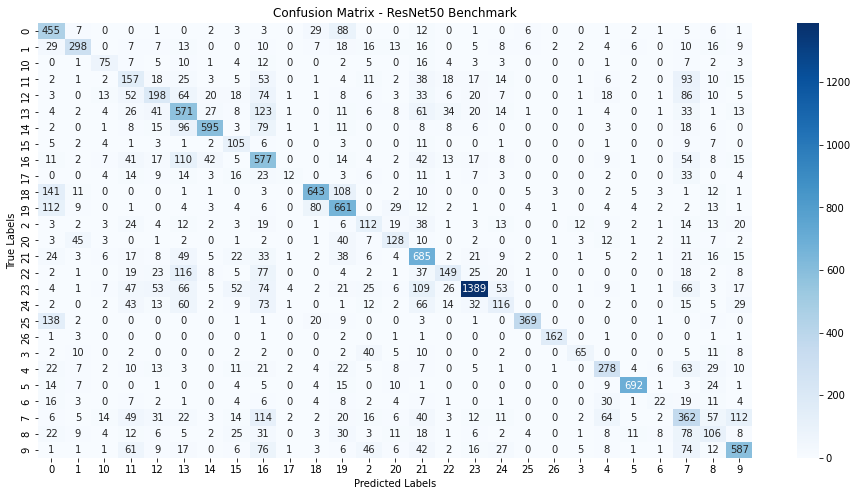

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - ResNet50 Benchmark")
plt.show()

# 8. Save Benchmark ResNet50 Model

In [28]:
# Reload config to ensure updated paths
importlib.reload(config)

# Define save path
benchmark_model_path = Path(config.BENCHMARK_IMG_MODEL_DIR) / "benchmark_resnet50_model.h5"

# Save model
model.save(benchmark_model_path)

print(f"[✔] Model saved at: {benchmark_model_path}")


[✔] Model saved at: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\models\image\benchmark\benchmark_resnet50_model.h5


# 9. Benchmark Results & Next Steps

 ###  Results:
- **Benchmark F1-score (given)**: `0.5534`
- **Our Model F1-score**: `0.5660`  
- **Precision**: `0.5917`
- **Recall**: `0.5634`  

 ### Observation:
Our implementation of the **ResNet50 benchmark model** slightly **outperforms the official reference** in terms of Weighted F1-score (`0.5660` vs. `0.5534`).
This validates our setup and provides a **solid baseline** for comparing future image classification models.

###  Next Steps:

We will now experiment with **alternative CNN architectures** to find models that offer better performance. Some of the models we will evaluate include:

- MobileNetV2

- DenseNet121

- Xception

- NASNetMobile

- InceptionV3

- InceptionResNetV2

- EfficientNetB7

-  VGG16, VGG19

After selecting the most promising models, we will apply **fine-tuning, **data augmentation**, and **learning rate optimization** and other techniques in order to outperform the benchmark model's performance.